In [ ]:
# Import Libaries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
# Fetching Dataset
df = pd.read_csv('../data/netflix_titles.csv')

# 1st look the data 

In [5]:
# rows and columns
print(df.shape)

(8807, 12)


# Firts 5 rows print(df.head(5))

In [7]:
# Columns types 
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [9]:
# Lets find the missing value 
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [10]:
# Fill the missing value 
df['director'].fillna('Unknown', inplace = True)  # Used to replace null value in director column
df['cast'].fillna('Unknown',inplace=True) # Used to replace null value in cast column
df['country'].fillna('Unknown',inplace=True) # # Used to replace null value in Country column
df['rating'].fillna('Not Rated',inplace=True) # # Used to replace null value in rating column

C:\Users\Aashish\AppData\Local\Temp\ipykernel_4100\772150307.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace = True)  # Used to replace null value in director column
C:\Users\Aashish\AppData\Local\Temp\ipykernel_4100\772150307.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are 

In [11]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [12]:
# Extracts Numeric Duration for Movies
movies = df[df['type'] == 'Movie'].copy()
movies['minutes'] = movies['duration'].str.replace('min', '').fillna('0').astype(int)

In [11]:
# EDA Exploratory Data Analysis

In [13]:
# Movie vs Tv Shows
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [14]:
# Content Added Per year
yeraly = df.groupby('year_added')['show_id'].count()
print(yeraly.sort_index())

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: show_id, dtype: int64


In [15]:
# Top 10 Countries'
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [18]:
# Top Genres
genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = genres.value_counts().head(15)
print(top_genres)

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64


In [16]:
print(df.isnull().sum())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      10
month_added     10
dtype: int64


In [19]:
# Rating Distribution 
ratings = df['rating'].value_counts()
print(ratings)

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
66 min          1
74 min          1
84 min          1
Name: count, dtype: int64


# Visualization 

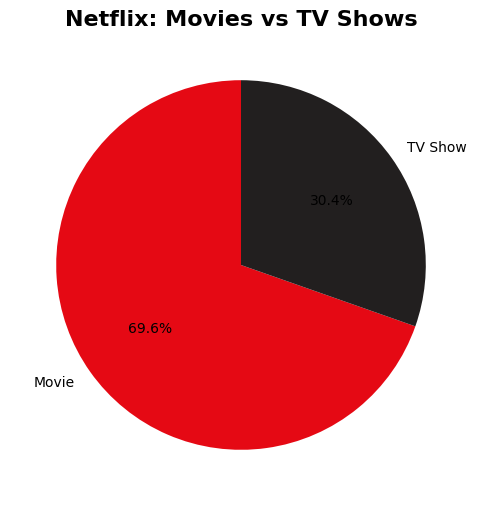

In [21]:
# Movies vs TV Shows (Pie Chart)
plt.figure(figsize=(8,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#E50914','#221F1F'], startangle=90)
plt.title('Netflix: Movies vs TV Shows', fontsize=16, fontweight='bold')
plt.savefig('../charts/movies_vs_shows.png', dpi=150, bbox_inches='tight')
plt.show()

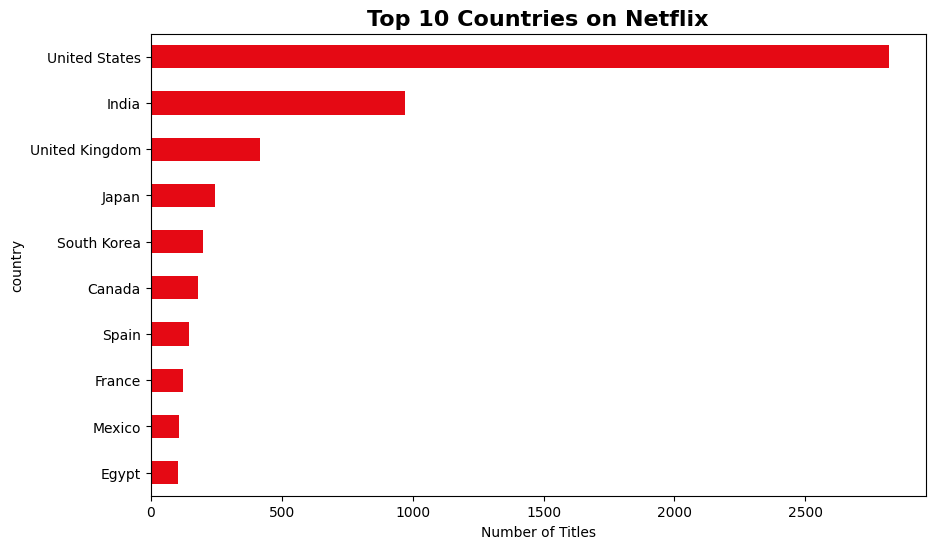

In [28]:
# Top 10 Countries 
plt.figure(figsize=(10,6))
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
top_countries.plot(kind='barh', color='#E50914')
plt.title('Top 10 Countries on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.savefig('../charts/top_countries.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Aashish\AppData\Local\Temp\ipykernel_4100\2886998527.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ratings.index[:10], y=ratings.values[:10], palette='Reds_r')


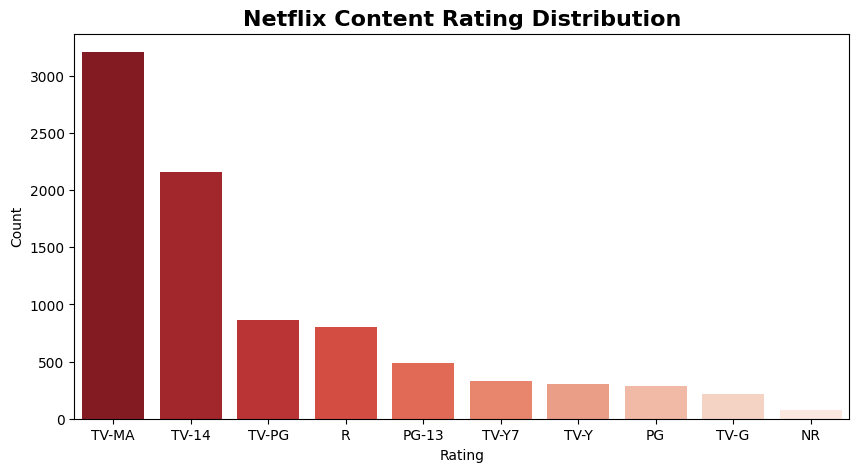

In [30]:
# Rating Distribution 
plt.figure(figsize=(10,5))
sns.barplot(x=ratings.index[:10], y=ratings.values[:10], palette='Reds_r')
plt.title('Netflix Content Rating Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Rating'); plt.ylabel('Count')
plt.savefig('../charts/ratings.png', dpi=150, bbox_inches='tight')
plt.show()


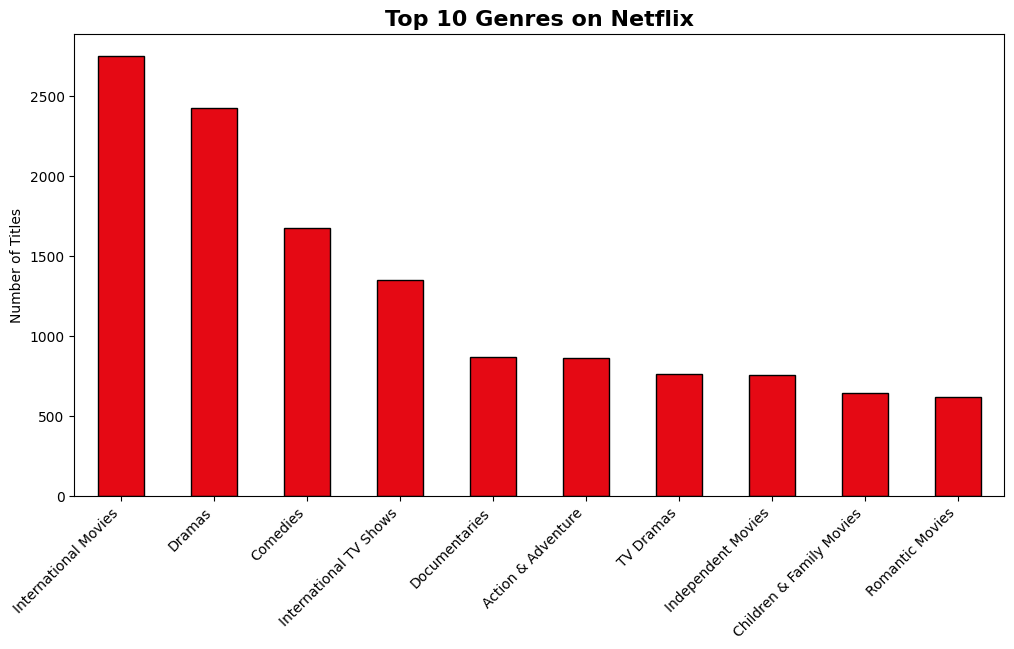

In [31]:
# Top Genres 
plt.figure(figsize=(12,6))
top_genres.head(10).plot(kind='bar', color='#E50914', edgecolor='black')
plt.title('Top 10 Genres on Netflix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Titles')
plt.savefig('../charts/top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical Summary

In [32]:
print('=====NETFLEX DATA SUMMARY======')
print(f'Total Titles: {len(df):,}')
print(f'Movies : {len(df[df.type =='Movie']):,}')
print(f'TV Shows: {len(df[df.type=="TV Show"]):,}')
print(f'Countries Represented: {df.country.nunique()}')
print(f'Year Range: {df.release_year.min()} - {df.release_year.max()}')
print(f'Avg Movie Duration: {movies.minutes.mean():.1f} minutes')
print(f'Most Common Rating: {df.rating.mode()[0]}')

=====NETFLEX DATA SUMMARY======
Total Titles: 8,807
Movies : 6,131
TV Shows: 2,676
Countries Represented: 749
Year Range: 1925 - 2021
Avg Movie Duration: 99.5 minutes
Most Common Rating: TV-MA


# Export Results to Excel

In [33]:
with pd.ExcelWriter('../report/netflix_analysis.xlsx', engine='openpyxl') as writer:
    df.describe().to_excel(writer, sheet_name='Summary Stats')
    type_counts.to_frame().to_excel(writer, sheet_name='Type Distribution')
    top_countries.to_frame().to_excel(writer, sheet_name='Top Countries')
    top_genres.to_frame().to_excel(writer, sheet_name='Top Genres')
    ratings.to_frame().to_excel(writer, sheet_name='Ratings')
print('Excel file saved!')

Excel file saved!


In [34]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [36]:
newdf = df.to_csv('../data/Netflix_clear.csv')